In [1]:
!pip install -q --upgrade "transformers>=4.46" "peft>=0.12" "accelerate>=0.30" \
    "scikit-learn>=1.3" "pandas" "pillow<12.0" "tqdm" "matplotlib" "opencv-python-headless"
!pip install -q -U "torchao>=0.16.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 287.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incomp

In [2]:
import torch, sys
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__, "| CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("AVISO: nenhuma GPU detectada. Vá em Ambiente de execução > Alterar tipo > GPU.")

Python: 3.12.13
Torch: 2.11.0+cu128 | CUDA disponível: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM total: 102.0 GB


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
CSV_PATH    = "/content/drive/MyDrive/BRSET/labels_brset.csv"
IMAGES_DIR  = "/content/drive/MyDrive/BRSET/fundus_photos"
OUTPUT_DIR  = "/content/drive/MyDrive/BRSET/retinascan_cbis/exp_1_2_brset_multilabel_all_images_robust_circle_clahe"

TASK_NAME = "BRSET multilabel — DINOv3+LoRA image-only — all images + robust circle crop + CLAHE"
MODEL_NAME = "facebook/dinov3-vitb16-pretrain-lvd1689m"
IMAGE_SIZE = 512

EXCLUDE_INADEQUATE_QUALITY = False
MIN_POSITIVES_SEPARATE_LABEL = 15

USE_FILM_METADATA = False

USE_ROBUST_CIRCLE_CROP = True
CIRCLE_CROP_PADDING = 1.03
CIRCLE_DETECT_MAX_SIDE = 768
PRE_RESIZE_BEFORE_CROP = True
PRE_RESIZE_MAX_SIDE = 1200
USE_CLAHE = True
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID_SIZE = (8, 8)

BATCH_SIZE        = 4
GRAD_ACCUM_STEPS  = 4
NUM_WORKERS       = 8
EPOCHS            = 50
PATIENCE          = 7
LR                = 1e-4
HEAD_LR_MULT      = 3.0
WEIGHT_DECAY      = 1e-4
MAX_GRAD_NORM     = 1.0
USE_AMP           = True

LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05

LOSS_TYPE       = "asl"
ASL_GAMMA_NEG   = 4.0
ASL_GAMMA_POS   = 0.0
ASL_CLIP        = 0.05
POS_WEIGHT_MODE = "sqrt_cap"
POS_WEIGHT_CAP  = 10.0

N_FOLDS  = 3
VAL_SIZE = 0.15
SEED     = 42

RUN_TRAINING = True

In [5]:
import os, json, random, math
from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import cv2
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, precision_score, recall_score,
    hamming_loss, confusion_matrix
)
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
from peft import LoraConfig, get_peft_model
from transformers import AutoModel


def set_seed(seed: int = 42) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [6]:
def _largest_component_mask(mask: np.ndarray) -> np.ndarray:
    """Mantém apenas o maior componente conectado da máscara binária."""
    mask = mask.astype("uint8")
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        return mask.astype(bool)
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return labels == largest


def _resize_for_detection(img: np.ndarray, max_side: int = 768):
    """Reduz a imagem para detectar o círculo mais rapidamente e retorna a escala."""
    H, W = img.shape[:2]
    max_dim = max(H, W)

    if max_dim <= max_side:
        return img, 1.0

    scale = float(max_side) / float(max_dim)
    new_w = max(1, int(round(W * scale)))
    new_h = max(1, int(round(H * scale)))
    small = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return small, scale


def detect_fundus_square(
    pil_img: Image.Image,
    padding: float = 1.03,
    return_mask: bool = False,
    detect_max_side: int = None,
):
    """Detecta a região retinal e retorna crop quadrado baseado no círculo envolvente.

    Versão otimizada:
    - a detecção do círculo é feita em uma cópia reduzida da imagem;
    - centro e raio são reescalados para a resolução original;
    - evita passar milhões de pixels para `cv2.minEnclosingCircle`, que era o gargalo.
    """
    img = np.array(pil_img.convert("RGB"))
    H, W = img.shape[:2]

    if detect_max_side is None:
        detect_max_side = int(CIRCLE_DETECT_MAX_SIDE)

    if H < 10 or W < 10:
        info = {
            "status": "too_small",
            "cx": W / 2,
            "cy": H / 2,
            "radius": min(H, W) / 2,
            "side": min(H, W),
            "detect_scale": 1.0,
            "mask_area_frac": 0.0,
        }
        mask_full = np.zeros((H, W), dtype=bool)
        return (pil_img, info, mask_full) if return_mask else (pil_img, info)

    small, scale = _resize_for_detection(img, max_side=detect_max_side)
    hS, wS = small.shape[:2]

    hsv = cv2.cvtColor(small, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)

    s = hsv[..., 1]
    v = hsv[..., 2]

    v_thr = max(10, int(np.percentile(v, 1)) + 5)
    gray_thr = max(10, int(np.percentile(gray, 1)) + 5)

    mask_bright = (v > v_thr) | (gray > gray_thr)
    mask_color = s > 8
    mask = mask_bright & (mask_color | (gray > 25))

    mask = mask.astype("uint8") * 255

    k_open = max(3, int(round(min(hS, wS) * 0.010)))
    k_close = max(9, int(round(min(hS, wS) * 0.035)))
    if k_open % 2 == 0:
        k_open += 1
    if k_close % 2 == 0:
        k_close += 1

    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_open, k_open))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_close, k_close))

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)

    mask_bool_small = _largest_component_mask(mask > 0)

    if mask_bool_small.sum() < 0.05 * hS * wS:
        gray_fallback = gray > 10
        gray_fallback = cv2.morphologyEx(
            gray_fallback.astype("uint8") * 255,
            cv2.MORPH_CLOSE,
            kernel_close,
        ) > 0
        mask_bool_small = _largest_component_mask(gray_fallback)

    ys, xs = np.where(mask_bool_small)

    if len(xs) < 10:
        cx_small, cy_small = wS / 2.0, hS / 2.0
        radius_small = max(hS, wS) / 2.0
        status = "fallback_full_image"
    else:
        if len(xs) > 50000:
            idx = np.linspace(0, len(xs) - 1, 50000).astype(int)
            xs_fit = xs[idx]
            ys_fit = ys[idx]
        else:
            xs_fit = xs
            ys_fit = ys

        pts = np.column_stack([xs_fit, ys_fit]).astype(np.float32)
        (cx_small, cy_small), radius_small = cv2.minEnclosingCircle(pts)
        status = "ok"

    inv_scale = 1.0 / float(scale)
    cx = float(cx_small * inv_scale)
    cy = float(cy_small * inv_scale)
    radius = float(radius_small * inv_scale)

    side = int(np.ceil(2.0 * radius * float(padding)))
    side = max(16, side)

    max_reasonable_side = int(np.ceil(1.25 * max(H, W)))
    if side > max_reasonable_side:
        side = max_reasonable_side
        status = status + "_side_clipped"

    x0 = int(round(cx - side / 2))
    y0 = int(round(cy - side / 2))
    x1 = x0 + side
    y1 = y0 + side

    src_x0 = max(x0, 0)
    src_y0 = max(y0, 0)
    src_x1 = min(x1, W)
    src_y1 = min(y1, H)

    crop = np.zeros((side, side, 3), dtype=np.uint8)

    dst_x0 = src_x0 - x0
    dst_y0 = src_y0 - y0
    dst_x1 = dst_x0 + (src_x1 - src_x0)
    dst_y1 = dst_y0 + (src_y1 - src_y0)

    if src_x1 > src_x0 and src_y1 > src_y0:
        crop[dst_y0:dst_y1, dst_x0:dst_x1] = img[src_y0:src_y1, src_x0:src_x1]

    info = {
        "status": status,
        "cx": float(cx),
        "cy": float(cy),
        "radius": float(radius),
        "side": int(side),
        "x0": int(x0),
        "y0": int(y0),
        "x1": int(x1),
        "y1": int(y1),
        "mask_area_frac": float(mask_bool_small.mean()),
        "detect_scale": float(scale),
        "detect_shape": (int(hS), int(wS)),
    }

    crop_img = Image.fromarray(crop)

    if return_mask:
        return crop_img, info, mask_bool_small

    return crop_img, info


def pre_resize_before_crop(pil_img: Image.Image, max_side: int = None) -> Image.Image:
    """Reduz a imagem ainda no carregamento antes do crop/CLAHE.

    Como a entrada final do DINOv3 será 512×512, não precisamos manter imagens
    enormes no pipeline de CPU. Este passo é o que deixa o Dataset viável para treino.
    """
    if not PRE_RESIZE_BEFORE_CROP:
        return pil_img
    if max_side is None:
        max_side = int(PRE_RESIZE_MAX_SIDE)

    img = pil_img.copy()
    img.thumbnail((max_side, max_side), Image.Resampling.LANCZOS)
    return img


def robust_circle_crop(pil_img: Image.Image) -> Image.Image:
    if not USE_ROBUST_CIRCLE_CROP:
        return pil_img
    crop_img, _ = detect_fundus_square(
        pil_img,
        padding=CIRCLE_CROP_PADDING,
        return_mask=False,
        detect_max_side=CIRCLE_DETECT_MAX_SIDE,
    )
    return crop_img


def apply_clahe_pil(pil_img: Image.Image) -> Image.Image:
    """Aplica CLAHE no canal L do espaço LAB."""
    if not USE_CLAHE:
        return pil_img

    img = np.array(pil_img.convert("RGB"))
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=float(CLAHE_CLIP_LIMIT),
        tileGridSize=tuple(CLAHE_TILE_GRID_SIZE),
    )
    l2 = clahe.apply(l)

    lab2 = cv2.merge([l2, a, b])
    rgb2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb2)


def build_transforms(image_size: int = 512, train: bool = True) -> transforms.Compose:
    if train:
        return transforms.Compose([
            transforms.Lambda(robust_circle_crop),
            transforms.Lambda(apply_clahe_pil),
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Lambda(robust_circle_crop),
        transforms.Lambda(apply_clahe_pil),
        transforms.Resize((image_size, image_size), antialias=True),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


class BRSETMultilabelDataset(Dataset):
    def __init__(self, df, images_dir, label_cols, transform=None, image_ext=".jpg", metadata_cols=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.label_cols = list(label_cols)
        self.transform = transform
        self.image_ext = image_ext
        self.metadata_cols = list(metadata_cols or [])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.images_dir, f"{row['image_id']}{self.image_ext}")
        img = Image.open(path).convert("RGB")
        img = pre_resize_before_crop(img, max_side=PRE_RESIZE_MAX_SIDE)
        if self.transform is not None:
            img = self.transform(img)
        y = torch.tensor(row[self.label_cols].astype("float32").to_numpy(), dtype=torch.float32)
        if self.metadata_cols:
            meta = torch.tensor(row[self.metadata_cols].astype("float32").to_numpy(), dtype=torch.float32)
            return img, meta, y
        return img, y

In [7]:
class WeightedAsymmetricLoss(nn.Module):
    """Asymmetric Loss para multilabel com pesos positivos suavizados.

    Boa para multilabel desbalanceado: reduz o peso de negativos fáceis e evita que
    a loss seja dominada por ausências de doença.
    """
    def __init__(self, gamma_neg=4.0, gamma_pos=0.0, clip=0.05, eps=1e-8, pos_weight=None):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps
        if pos_weight is not None:
            self.register_buffer("pos_weight", torch.as_tensor(pos_weight, dtype=torch.float32))
        else:
            self.pos_weight = None

    def forward(self, logits, targets):
        x_sigmoid = torch.sigmoid(logits)
        xs_pos = x_sigmoid
        xs_neg = 1.0 - x_sigmoid

        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)

        los_pos = targets * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1.0 - targets) * torch.log(xs_neg.clamp(min=self.eps))

        if self.pos_weight is not None:
            los_pos = los_pos * self.pos_weight.view(1, -1)

        if self.gamma_neg > 0 or self.gamma_pos > 0:
            pt = xs_pos * targets + xs_neg * (1.0 - targets)
            gamma = self.gamma_pos * targets + self.gamma_neg * (1.0 - targets)
            los_pos = los_pos * ((1.0 - pt) ** gamma)
            los_neg = los_neg * ((1.0 - pt) ** gamma)

        return -(los_pos + los_neg).mean()


def compute_pos_weight(y_train: np.ndarray, mode="sqrt_cap", cap=10.0) -> np.ndarray:
    pos = y_train.sum(axis=0).astype(float)
    neg = y_train.shape[0] - pos
    raw = neg / np.maximum(pos, 1.0)
    if mode == "none":
        w = np.ones_like(raw)
    elif mode == "raw_cap":
        w = np.minimum(raw, cap)
    elif mode == "sqrt_cap":
        w = np.minimum(np.sqrt(raw), cap)
    else:
        raise ValueError(f"POS_WEIGHT_MODE inválido: {mode}")
    return np.maximum(w, 1.0).astype("float32")


def safe_auc_roc(y, s):
    return np.nan if len(np.unique(y)) < 2 else float(roc_auc_score(y, s))


def safe_auc_pr(y, s):
    return np.nan if y.sum() == 0 else float(average_precision_score(y, s))


def best_f1_thresholds(y_true: np.ndarray, scores: np.ndarray, grid=None) -> np.ndarray:
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    thresholds = []
    for c in range(y_true.shape[1]):
        yt, sc = y_true[:, c], scores[:, c]
        if yt.sum() == 0:
            thresholds.append(0.5)
            continue
        f1s = [f1_score(yt, sc >= t, zero_division=0) for t in grid]
        thresholds.append(float(grid[int(np.argmax(f1s))]))
    return np.asarray(thresholds, dtype="float32")


def compute_multilabel_metrics(y_true: np.ndarray, scores: np.ndarray, thresholds: np.ndarray, label_cols: List[str]):
    y_pred = (scores >= thresholds.reshape(1, -1)).astype(int)
    per_class = []
    for i, name in enumerate(label_cols):
        yt, yp, sc = y_true[:, i].astype(int), y_pred[:, i].astype(int), scores[:, i]
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        per_class.append({
            "label": name,
            "support": int(yt.sum()),
            "threshold": float(thresholds[i]),
            "auc_roc": safe_auc_roc(yt, sc),
            "auc_pr": safe_auc_pr(yt, sc),
            "f1": float(f1_score(yt, yp, zero_division=0)),
            "precision": float(precision_score(yt, yp, zero_division=0)),
            "recall": float(recall_score(yt, yp, zero_division=0)),
            "specificity": float(specificity),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        })
    pc = pd.DataFrame(per_class)
    summary = {
        "macro_auc_roc": float(np.nanmean(pc["auc_roc"])),
        "macro_auc_pr": float(np.nanmean(pc["auc_pr"])),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "micro_f1": float(f1_score(y_true, y_pred, average="micro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "samples_f1": float(f1_score(y_true, y_pred, average="samples", zero_division=0)),
        "micro_auc_pr": float(average_precision_score(y_true, scores, average="micro")),
        "hamming_loss": float(hamming_loss(y_true, y_pred)),
    }
    return summary, pc, y_pred

In [8]:
class DINOv3LoRAMultilabelClassifier(nn.Module):
    def __init__(
        self,
        model_name="facebook/dinov3-vitb16-pretrain-lvd1689m",
        num_labels=9,
        lora_r=16, lora_alpha=32, lora_dropout=0.05,
        target_modules=None,
        head_dropout=0.1,
        freeze_backbone=True,
        meta_dim=0,
        meta_hidden_dim=128,
        film_dropout=0.20,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.meta_dim = int(meta_dim)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        if target_modules is None:
            target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj"]

        lora_cfg = LoraConfig(
            r=lora_r, lora_alpha=lora_alpha, lora_dropout=lora_dropout,
            target_modules=target_modules, bias="none", task_type=None,
        )
        self.backbone = get_peft_model(self.backbone, lora_cfg)

        if self.meta_dim > 0:
            self.meta_encoder = nn.Sequential(
                nn.Linear(self.meta_dim, meta_hidden_dim),
                nn.LayerNorm(meta_hidden_dim),
                nn.GELU(),
                nn.Dropout(film_dropout),
                nn.Linear(meta_hidden_dim, meta_hidden_dim),
                nn.GELU(),
            )
            self.film = nn.Linear(meta_hidden_dim, hidden_size * 2)
            nn.init.zeros_(self.film.weight)
            nn.init.zeros_(self.film.bias)
        else:
            self.meta_encoder = None
            self.film = None

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(head_dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(hidden_size // 2, num_labels),
        )

    def _pool_dino_outputs(self, outputs):
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            return outputs.pooler_output
        return outputs.last_hidden_state[:, 5:, :].mean(dim=1)

    def forward(self, pixel_values, metadata=None):
        outputs = self.backbone(pixel_values=pixel_values)
        pooled = self._pool_dino_outputs(outputs)
        if self.meta_dim > 0:
            if metadata is None:
                raise ValueError("metadata=None, mas o modelo foi criado com meta_dim > 0.")
            meta_feat = self.meta_encoder(metadata.float())
            gamma_beta = self.film(meta_feat)
            gamma, beta = gamma_beta.chunk(2, dim=1)
            pooled = pooled * (1.0 + gamma) + beta
        return self.head(pooled)

    def trainable_parameter_count(self):
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return trainable, total

In [9]:
ORIGINAL_PATHOLOGY_COLS = [
    "diabetic_retinopathy",
    "macular_edema",
    "scar",
    "nevus",
    "amd",
    "vascular_occlusion",
    "hypertensive_retinopathy",
    "drusens",
    "hemorrhage",
    "retinal_detachment",
    "myopic_fundus",
    "increased_cup_disc",
    "other",
]


def build_multilabel_dataframe(raw_df: pd.DataFrame):
    df = raw_df.copy()
    df["image_id"] = df["image_id"].astype(str)
    df["patient_id"] = df["patient_id"].astype(str)

    missing = [c for c in ORIGINAL_PATHOLOGY_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Colunas patológicas ausentes no CSV: {missing}")

    for c in ORIGINAL_PATHOLOGY_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int).clip(0, 1)

    if EXCLUDE_INADEQUATE_QUALITY:
        before = len(df)
        if "quality" not in df.columns:
            raise ValueError("EXCLUDE_INADEQUATE_QUALITY=True, mas a coluna 'quality' não existe.")
        df = df[df["quality"].astype(str).str.lower().eq("adequate")].copy()
        print(f"Filtro de qualidade: removidas {before - len(df)} imagens inadequadas; mantidas {len(df)}.")
    else:
        print(f"Filtro de qualidade desativado: usando todas as {len(df)} imagens disponíveis no CSV.")
        if "quality" in df.columns:
            print("Distribuição de quality:")
            print(df["quality"].value_counts(dropna=False).to_string())

    counts = df[ORIGINAL_PATHOLOGY_COLS].sum().sort_values(ascending=False)
    rare_cols = [c for c, n in counts.items() if n < MIN_POSITIVES_SEPARATE_LABEL and c != "other"]
    separate_cols = [c for c in ORIGINAL_PATHOLOGY_COLS if c not in rare_cols and c != "other"]

    df["other_merged"] = df[["other"] + rare_cols].max(axis=1).astype(int)
    label_cols = separate_cols + ["other_merged"]

    print("Contagem original após filtros:")
    print(counts.to_string())
    print(f"\nClasses com < {MIN_POSITIVES_SEPARATE_LABEL} positivos fundidas em other_merged:")
    print(rare_cols if rare_cols else "nenhuma")
    print("\nLabels finais:")
    print(df[label_cols].sum().sort_values(ascending=False).to_string())

    return df.reset_index(drop=True), label_cols, rare_cols


raw_df = pd.read_csv(CSV_PATH)
df, LABEL_COLS, RARE_MERGED_COLS = build_multilabel_dataframe(raw_df)
NUM_LABELS = len(LABEL_COLS)
print(f"\nTotal imagens: {len(df)} | Total pacientes: {df['patient_id'].nunique()} | NUM_LABELS={NUM_LABELS}")

Filtro de qualidade desativado: usando todas as 16266 imagens disponíveis no CSV.
Distribuição de quality:
quality
Adequate      14280
Inadequate     1986
Contagem original após filtros:
increased_cup_disc          3205
drusens                     2833
diabetic_retinopathy        1070
other                        820
macular_edema                401
amd                          299
scar                         291
hypertensive_retinopathy     284
myopic_fundus                270
nevus                        130
vascular_occlusion           101
hemorrhage                    95
retinal_detachment             7

Classes com < 15 positivos fundidas em other_merged:
['retinal_detachment']

Labels finais:
increased_cup_disc          3205
drusens                     2833
diabetic_retinopathy        1070
other_merged                 827
macular_edema                401
amd                          299
scar                         291
hypertensive_retinopathy     284
myopic_fundus              

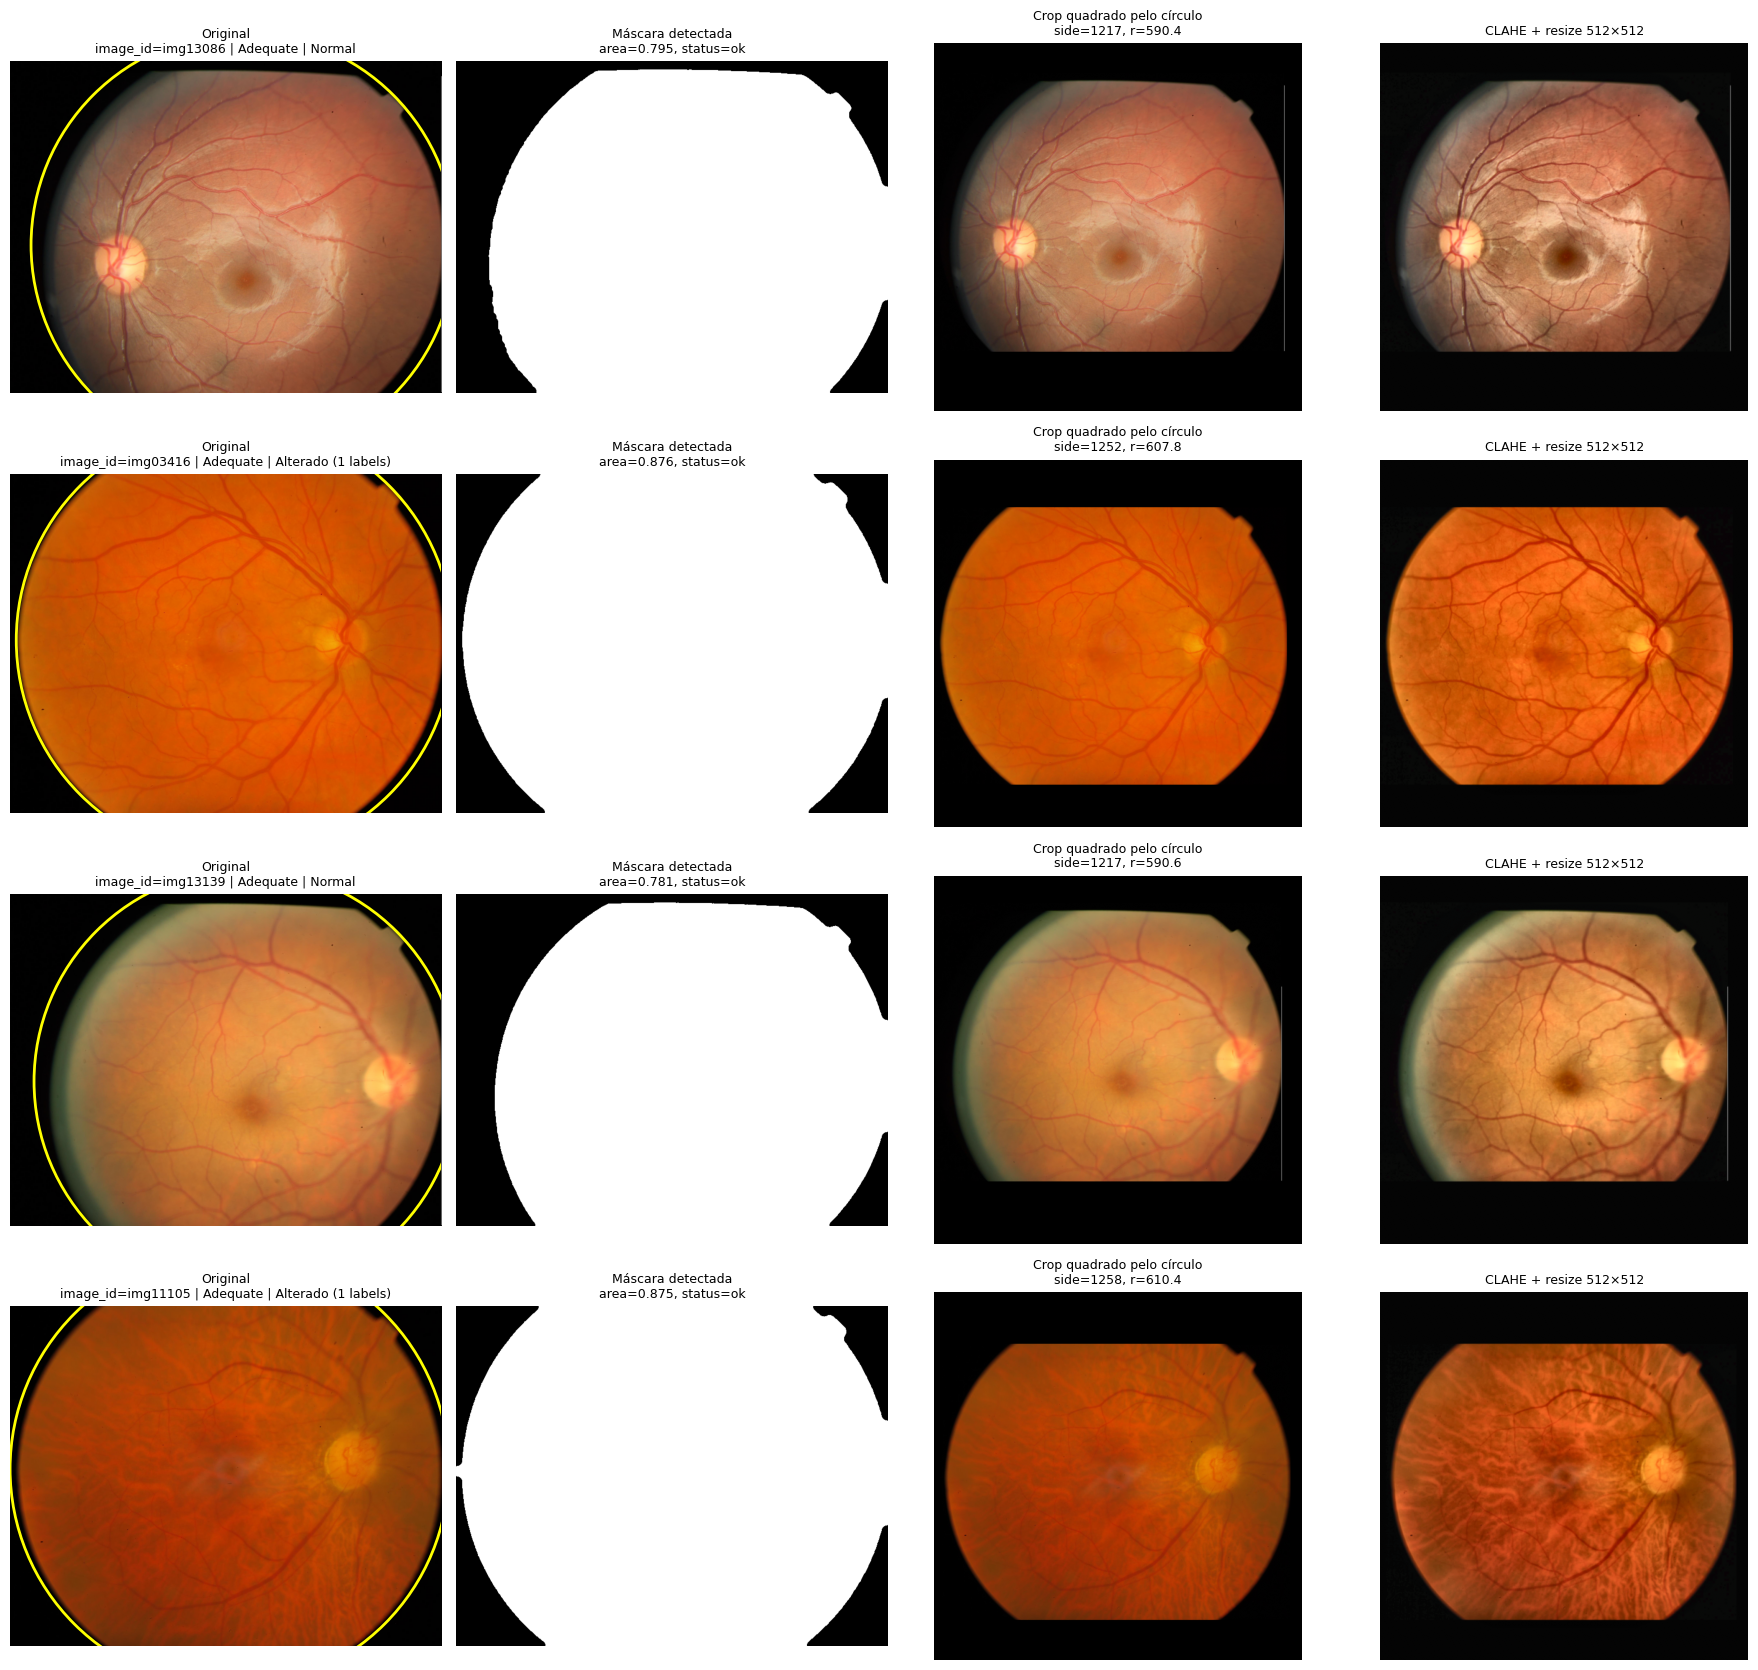

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def _load_brset_image(image_id):
    candidates = [
        os.path.join(IMAGES_DIR, f"{image_id}.jpg"),
        os.path.join(IMAGES_DIR, f"{image_id}.jpeg"),
        os.path.join(IMAGES_DIR, f"{image_id}.png"),
        os.path.join(IMAGES_DIR, str(image_id)),
    ]
    for p in candidates:
        if os.path.exists(p):
            return Image.open(p).convert("RGB")
    raise FileNotFoundError(f"Imagem não encontrada para image_id={image_id}")

def preview_robust_circle_crop_and_clahe(df_in, n_examples=4, seed=42):
    rng = np.random.default_rng(seed)

    normal_mask = df_in[LABEL_COLS].sum(axis=1) == 0
    abnormal_mask = ~normal_mask

    parts = []
    n_norm = min(n_examples // 2, int(normal_mask.sum()))
    n_abn = min(n_examples - n_norm, int(abnormal_mask.sum()))

    if n_norm > 0:
        parts.append(df_in[normal_mask].sample(n=n_norm, random_state=seed))
    if n_abn > 0:
        parts.append(df_in[abnormal_mask].sample(n=n_abn, random_state=seed + 1))

    if parts:
        sample_df = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    else:
        sample_df = df_in.sample(n=min(n_examples, len(df_in)), random_state=seed).reset_index(drop=True)

    resize_only = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    ])

    fig, axes = plt.subplots(len(sample_df), 4, figsize=(18, 4.2 * len(sample_df)))
    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(sample_df.iterrows()):
        image_id = row["image_id"]
        raw_img_full = _load_brset_image(image_id)
        raw_img = pre_resize_before_crop(raw_img_full, max_side=PRE_RESIZE_MAX_SIDE)
        raw_np = np.array(raw_img.convert("RGB"))

        crop_img, info, mask = detect_fundus_square(raw_img, padding=CIRCLE_CROP_PADDING, return_mask=True, detect_max_side=CIRCLE_DETECT_MAX_SIDE)
        clahe_img = apply_clahe_pil(crop_img)
        resized_img = resize_only(clahe_img)

        crop_np = np.array(crop_img) / 255.0
        resized_np = np.array(resized_img) / 255.0

        label_count = int(row[LABEL_COLS].sum())
        label_text = "Normal" if label_count == 0 else f"Alterado ({label_count} labels)"
        quality_text = row.get("quality", "NA")

        axes[i, 0].imshow(raw_np)
        axes[i, 0].set_title(f"Original\nimage_id={image_id} | {quality_text} | {label_text}", fontsize=9)
        axes[i, 0].axis("off")

        circ = patches.Circle(
            (info["cx"], info["cy"]),
            info["radius"],
            fill=False,
            linewidth=2,
            edgecolor="yellow",
        )
        axes[i, 0].add_patch(circ)

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(f"Máscara detectada\narea={info['mask_area_frac']:.3f}, status={info['status']}", fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(crop_np)
        axes[i, 2].set_title(f"Crop quadrado pelo círculo\nside={info['side']}, r={info['radius']:.1f}", fontsize=9)
        axes[i, 2].axis("off")

        axes[i, 3].imshow(resized_np)
        axes[i, 3].set_title("CLAHE + resize 512×512", fontsize=9)
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

preview_robust_circle_crop_and_clahe(df, n_examples=4, seed=SEED)

In [14]:
import time

def benchmark_crop_speed(df_in, n=5, seed=SEED):
    sample_df = df_in.sample(n=min(n, len(df_in)), random_state=seed).reset_index(drop=True)
    times = []
    for _, row in sample_df.iterrows():
        image_id = row["image_id"]
        path = os.path.join(IMAGES_DIR, f"{image_id}.jpg")
        t0 = time.time()
        img = Image.open(path).convert("RGB")
        t_load = time.time()
        crop_img, info, _ = detect_fundus_square(
            img,
            padding=CIRCLE_CROP_PADDING,
            return_mask=True,
            detect_max_side=CIRCLE_DETECT_MAX_SIDE,
        )
        t_crop = time.time()
        _ = apply_clahe_pil(crop_img)
        t_clahe = time.time()

        row_time = {
            "image_id": image_id,
            "load_s": round(t_load - t0, 3),
            "crop_s": round(t_crop - t_load, 3),
            "clahe_s": round(t_clahe - t_crop, 3),
            "total_s": round(t_clahe - t0, 3),
            "status": info["status"],
            "side": info["side"],
            "detect_scale": round(info["detect_scale"], 3),
            "detect_shape": info["detect_shape"],
        }
        times.append(row_time)
        print(row_time)

    return pd.DataFrame(times)

benchmark_crop_speed(df, n=5, seed=SEED)

{'image_id': 'img00388', 'load_s': 0.019, 'crop_s': 0.11, 'clahe_s': 0.016, 'total_s': 0.146, 'status': 'ok', 'side': 2493, 'detect_scale': 0.321, 'detect_shape': (604, 768)}
{'image_id': 'img01262', 'load_s': 0.648, 'crop_s': 0.222, 'clahe_s': 0.018, 'total_s': 0.888, 'status': 'ok', 'side': 2633, 'detect_scale': 0.287, 'detect_shape': (591, 768)}
{'image_id': 'img02547', 'load_s': 1.515, 'crop_s': 0.129, 'clahe_s': 0.027, 'total_s': 1.67, 'status': 'ok', 'side': 3045, 'detect_scale': 0.257, 'detect_shape': (593, 768)}
{'image_id': 'img00285', 'load_s': 0.547, 'crop_s': 0.177, 'clahe_s': 0.002, 'total_s': 0.726, 'status': 'ok', 'side': 872, 'detect_scale': 0.808, 'detect_shape': (706, 768)}
{'image_id': 'img07199', 'load_s': 0.816, 'crop_s': 0.193, 'clahe_s': 0.016, 'total_s': 1.025, 'status': 'ok', 'side': 2606, 'detect_scale': 0.287, 'detect_shape': (591, 768)}


,image_id,load_s,crop_s,clahe_s,total_s,status,side,detect_scale,detect_shape
0,img00388,0.019,0.110,0.016,0.146,ok,2493,0.321,"(604, 768)"
1,img01262,0.648,0.222,0.018,0.888,ok,2633,0.287,"(591, 768)"
2,img02547,1.515,0.129,0.027,1.670,ok,3045,0.257,"(593, 768)"
3,img00285,0.547,0.177,0.002,0.726,ok,872,0.808,"(706, 768)"
4,img07199,0.816,0.193,0.016,1.025,ok,2606,0.287,"(591, 768)"


In [15]:
METADATA_FEATURE_COLS = [
    "patient_age_z",
    "patient_age_missing",
    "sex_male",
    "diabetes_yes",
    "hypertension_yes",
]


def _yes_to_int(s):
    return s.astype(str).str.lower().str.strip().eq("yes").astype(int)


def add_fold_metadata_features(train_df, val_df, test_df):
    train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()

    age_median = float(train_df["patient_age"].median())
    for part in [train_df, val_df, test_df]:
        part["patient_age_missing"] = part["patient_age"].isna().astype("float32")
        part["patient_age_filled"] = part["patient_age"].fillna(age_median).astype(float)

    age_mean = float(train_df["patient_age_filled"].mean())
    age_std = float(train_df["patient_age_filled"].std(ddof=0))
    if not np.isfinite(age_std) or age_std < 1e-6:
        age_std = 1.0

    for part in [train_df, val_df, test_df]:
        part["patient_age_z"] = ((part["patient_age_filled"] - age_mean) / age_std).astype("float32")
        part["sex_male"] = (pd.to_numeric(part["patient_sex"], errors="coerce").fillna(0).astype(int) == 1).astype("float32")
        part["diabetes_yes"] = _yes_to_int(part["diabetes"]).astype("float32")
        part["hypertension_yes"] = (
            part["comorbidities"].fillna("").astype(str).str.lower().str.contains("hypertens", regex=False)
        ).astype("float32")

    params = {
        "age_median_train": age_median,
        "age_mean_train_after_imputation": age_mean,
        "age_std_train_after_imputation": age_std,
        "metadata_cols": METADATA_FEATURE_COLS,
    }
    return train_df, val_df, test_df, params

In [16]:
!pip -q install iterative-stratification

import numpy as np
import pandas as pd

from iterstrat.ml_stratifiers import (
    MultilabelStratifiedKFold,
    MultilabelStratifiedShuffleSplit,
)


def build_patient_label_table(df, label_cols, patient_col="patient_id"):
    """
    Agrega labels no nível do paciente.
    Se qualquer imagem do paciente tem uma label positiva,
    o paciente é considerado positivo para aquela label.
    """
    patient_labels = (
        df.groupby(patient_col)[label_cols]
        .max()
        .reset_index()
    )

    patient_n_images = (
        df.groupby(patient_col)
        .size()
        .rename("n_images")
        .reset_index()
    )

    patient_table = patient_labels.merge(
        patient_n_images,
        on=patient_col,
        how="left",
    )

    return patient_table


def assert_no_patient_leakage(train_df, val_df, test_df, fold_idx, patient_col="patient_id"):
    train_patients = set(train_df[patient_col].unique())
    val_patients = set(val_df[patient_col].unique())
    test_patients = set(test_df[patient_col].unique())

    leak_train_val = train_patients & val_patients
    leak_train_test = train_patients & test_patients
    leak_val_test = val_patients & test_patients

    if leak_train_val or leak_train_test or leak_val_test:
        raise ValueError(
            f"[fold {fold_idx}] Vazamento de paciente detectado!\n"
            f"train ∩ val: {len(leak_train_val)}\n"
            f"train ∩ test: {len(leak_train_test)}\n"
            f"val ∩ test: {len(leak_val_test)}"
        )

    print(f"[fold {fold_idx}] ✓ Sem vazamento de paciente.")


def assert_all_labels_present(train_df, val_df, test_df, label_cols, fold_idx):
    """
    Para multilabel, cada classe precisa ter positivos no treino,
    na validação e no teste. Sem isso, a loss/threshold/métrica por classe
    ficam inválidos ou instáveis.
    """
    train_counts = train_df[label_cols].sum()
    val_counts = val_df[label_cols].sum()
    test_counts = test_df[label_cols].sum()

    missing_train = train_counts[train_counts == 0].index.tolist()
    missing_val = val_counts[val_counts == 0].index.tolist()
    missing_test = test_counts[test_counts == 0].index.tolist()

    if missing_train or missing_val or missing_test:
        raise ValueError(
            f"[fold {fold_idx}] Split multilabel inválido.\n"
            f"Classes sem positivos no treino: {missing_train}\n"
            f"Classes sem positivos na validação: {missing_val}\n"
            f"Classes sem positivos no teste: {missing_test}"
        )


def print_split_summary(train_df, val_df, test_df, label_cols, fold_idx, patient_col="patient_id"):
    print(f"\n=========== FOLD {fold_idx} ===========")
    print(
        f"  Pacientes: "
        f"train={train_df[patient_col].nunique()} | "
        f"val={val_df[patient_col].nunique()} | "
        f"test={test_df[patient_col].nunique()}"
    )
    print(
        f"  Imagens:   "
        f"train={len(train_df)} | "
        f"val={len(val_df)} | "
        f"test={len(test_df)}"
    )

    summary = pd.DataFrame({
        "train": train_df[label_cols].sum().astype(int),
        "val": val_df[label_cols].sum().astype(int),
        "test": test_df[label_cols].sum().astype(int),
    })

    display(summary)

    return summary


def make_patientwise_multilabel_folds(
    df,
    label_cols,
    n_folds=3,
    val_size=0.15,
    seed=42,
    patient_col="patient_id",
):
    """
    Cria folds multilabel estratificados por paciente.

    Passo 1:
      separa trainval/test usando MultilabelStratifiedKFold.

    Passo 2:
      dentro do trainval, separa train/val usando
      MultilabelStratifiedShuffleSplit.

    Importante:
      a estratificação é feita no nível do paciente, não da imagem.
    """

    patient_table = build_patient_label_table(
        df,
        label_cols=label_cols,
        patient_col=patient_col,
    ).reset_index(drop=True)

    X_dummy = np.zeros((len(patient_table), 1))
    Y = patient_table[label_cols].values.astype(int)

    outer_splitter = MultilabelStratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=seed,
    )

    folds = []

    for fold_idx, (trainval_idx, test_idx) in enumerate(
        outer_splitter.split(X_dummy, Y)
    ):
        trainval_patients = patient_table.iloc[trainval_idx].reset_index(drop=True)
        test_patients = patient_table.iloc[test_idx].reset_index(drop=True)

        X_inner = np.zeros((len(trainval_patients), 1))
        Y_inner = trainval_patients[label_cols].values.astype(int)

        inner_splitter = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=val_size,
            random_state=seed + 1000 + fold_idx,
        )

        inner_train_idx, inner_val_idx = next(
            inner_splitter.split(X_inner, Y_inner)
        )

        train_patients = trainval_patients.iloc[inner_train_idx]
        val_patients = trainval_patients.iloc[inner_val_idx]

        train_df = df[
            df[patient_col].isin(train_patients[patient_col])
        ].reset_index(drop=True)

        val_df = df[
            df[patient_col].isin(val_patients[patient_col])
        ].reset_index(drop=True)

        test_df = df[
            df[patient_col].isin(test_patients[patient_col])
        ].reset_index(drop=True)

        assert_no_patient_leakage(
            train_df,
            val_df,
            test_df,
            fold_idx=fold_idx,
            patient_col=patient_col,
        )

        assert_all_labels_present(
            train_df,
            val_df,
            test_df,
            label_cols=label_cols,
            fold_idx=fold_idx,
        )

        print_split_summary(
            train_df,
            val_df,
            test_df,
            label_cols=label_cols,
            fold_idx=fold_idx,
            patient_col=patient_col,
        )

        folds.append((train_df, val_df, test_df))

    return folds

In [17]:
def amp_dtype_for_device(device):
    if device.type != "cuda":
        return torch.float32
    return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


def unpack_batch(batch, device):
    if len(batch) == 3:
        imgs, metadata, labels = batch
        return imgs.to(device, non_blocking=True), metadata.to(device, non_blocking=True), labels.to(device, non_blocking=True)
    imgs, labels = batch
    return imgs.to(device, non_blocking=True), None, labels.to(device, non_blocking=True)


def forward_model(model, imgs, metadata=None):
    if metadata is None:
        return model(imgs)
    return model(imgs, metadata)


def evaluate(model, loader, device, use_amp=True):
    model.eval()
    all_scores, all_labels = [], []
    amp_dtype = amp_dtype_for_device(device)
    amp_enabled = bool(use_amp and device.type == "cuda")
    with torch.no_grad():
        for batch in loader:
            imgs, metadata, labels = unpack_batch(batch, device)
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled, dtype=amp_dtype):
                logits = forward_model(model, imgs, metadata)
            probs = torch.sigmoid(logits).float().cpu().numpy()
            all_scores.append(probs)
            all_labels.append(labels.cpu().numpy())
    return np.vstack(all_labels), np.vstack(all_scores)


def safe_torch_load(path, map_location="cpu"):
    """Carrega checkpoints gerados por este notebook no PyTorch >= 2.6."""
    return torch.load(path, map_location=map_location, weights_only=False)


def best_f1_threshold_binary(y_true, scores, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)
    if y_true.sum() == 0:
        return 0.5
    f1s = [f1_score(y_true, scores >= t, zero_division=0) for t in grid]
    return float(grid[int(np.argmax(f1s))])


def compute_binary_metrics_from_scores(y_true, scores, threshold):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores).astype(float)
    y_pred = (scores >= float(threshold)).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    bal_acc = np.nanmean([sens, spec])
    return {
        "threshold": float(threshold),
        "auc_roc": safe_auc_roc(y_true, scores),
        "auc_pr": safe_auc_pr(y_true, scores),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(spec),
        "balanced_accuracy": float(bal_acc),
        "accuracy": float((y_true == y_pred).mean()),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }, y_pred


def compute_normal_vs_altered_metrics(y_true_ml, scores_ml, thresholds_ml, val_abnormal_threshold=None):
    """Avalia o modelo multilabel como binário: normal vs alterado.

    Duas leituras são geradas:
    1) any_class_thresholds: alterado se qualquer classe passou seu threshold por classe.
    2) max_score_threshold_from_val: alterado se max(score das classes) passou um threshold único
       escolhido na validação. Essa opção exige `val_abnormal_threshold`.
    """
    y_true_abn = (np.asarray(y_true_ml).astype(int).sum(axis=1) > 0).astype(int)
    scores_abn = np.asarray(scores_ml).max(axis=1)

    rows = []

    y_pred_ml = (np.asarray(scores_ml) >= np.asarray(thresholds_ml).reshape(1, -1)).astype(int)
    y_pred_abn_any = (y_pred_ml.sum(axis=1) > 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_abn, y_pred_abn_any, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    rows.append({
        "mode": "any_class_thresholds",
        "threshold": np.nan,
        "auc_roc": safe_auc_roc(y_true_abn, scores_abn),
        "auc_pr": safe_auc_pr(y_true_abn, scores_abn),
        "f1": float(f1_score(y_true_abn, y_pred_abn_any, zero_division=0)),
        "precision": float(precision_score(y_true_abn, y_pred_abn_any, zero_division=0)),
        "recall_sensitivity": float(recall_score(y_true_abn, y_pred_abn_any, zero_division=0)),
        "specificity": float(spec),
        "balanced_accuracy": float(np.nanmean([sens, spec])),
        "accuracy": float((y_true_abn == y_pred_abn_any).mean()),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    })

    if val_abnormal_threshold is not None and np.isfinite(val_abnormal_threshold):
        m, _ = compute_binary_metrics_from_scores(y_true_abn, scores_abn, val_abnormal_threshold)
        rows.append({"mode": "max_score_threshold_from_val", **m})

    return pd.DataFrame(rows)


def save_prediction_table(path, base_df, y_true, scores, y_pred, label_cols, metadata_cols=None):
    pred_df = base_df[["image_id", "patient_id"]].copy()
    for i, c in enumerate(label_cols):
        pred_df[f"y_true_{c}"] = y_true[:, i].astype(int)
        pred_df[f"score_{c}"] = scores[:, i]
        pred_df[f"y_pred_{c}"] = y_pred[:, i].astype(int)
    if metadata_cols:
        for c in metadata_cols:
            if c in base_df.columns:
                pred_df[c] = base_df[c].values
    pred_df.to_csv(path, index=False)
    return pred_df


def prepare_fold_datasets(train_df, val_df, test_df):
    metadata_cols = []
    meta_params = None
    if USE_FILM_METADATA:
        train_df, val_df, test_df, meta_params = add_fold_metadata_features(train_df, val_df, test_df)
        metadata_cols = METADATA_FEATURE_COLS

    train_tf = build_transforms(IMAGE_SIZE, train=True)
    eval_tf = build_transforms(IMAGE_SIZE, train=False)

    train_ds = BRSETMultilabelDataset(train_df, IMAGES_DIR, LABEL_COLS, transform=train_tf, metadata_cols=metadata_cols)
    val_ds   = BRSETMultilabelDataset(val_df,   IMAGES_DIR, LABEL_COLS, transform=eval_tf,   metadata_cols=metadata_cols)
    test_ds  = BRSETMultilabelDataset(test_df,  IMAGES_DIR, LABEL_COLS, transform=eval_tf,   metadata_cols=metadata_cols)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=True, persistent_workers=(NUM_WORKERS > 0))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=True, persistent_workers=(NUM_WORKERS > 0))
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=True, persistent_workers=(NUM_WORKERS > 0))
    return train_df, val_df, test_df, metadata_cols, meta_params, train_loader, val_loader, test_loader


def build_model(metadata_cols, device):
    model = DINOv3LoRAMultilabelClassifier(
        model_name=MODEL_NAME, num_labels=NUM_LABELS,
        lora_r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
        meta_dim=len(metadata_cols),
    ).to(device)
    return model


def load_checkpoint_into_model(model, ckpt_path, device):
    blob = safe_torch_load(ckpt_path, map_location=device)
    current = model.state_dict()
    current.update(blob["state_dict"])
    model.load_state_dict(current)
    thresholds = np.asarray(blob["best_thresholds"], dtype="float32")
    return blob, thresholds


def train_one_fold(fold_idx, train_df, val_df, test_df, device):
    out_dir = os.path.join(OUTPUT_DIR, f"fold_{fold_idx}")
    os.makedirs(out_dir, exist_ok=True)

    train_df, val_df, test_df, metadata_cols, meta_params, train_loader, val_loader, test_loader = prepare_fold_datasets(train_df, val_df, test_df)
    if USE_FILM_METADATA:
        with open(os.path.join(out_dir, "metadata_params.json"), "w") as f:
            json.dump(meta_params, f, indent=2)

    model = build_model(metadata_cols, device)
    trainable, total = model.trainable_parameter_count()
    print(f"[fold {fold_idx}] Parâmetros treináveis: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

    y_train = train_df[LABEL_COLS].values.astype("float32")
    pos_weight = compute_pos_weight(y_train, mode=POS_WEIGHT_MODE, cap=POS_WEIGHT_CAP)
    print(f"[fold {fold_idx}] pos_weight usado na loss:")
    print(pd.Series(pos_weight, index=LABEL_COLS).round(3).to_string())

    if LOSS_TYPE == "asl":
        criterion = WeightedAsymmetricLoss(
            gamma_neg=ASL_GAMMA_NEG, gamma_pos=ASL_GAMMA_POS, clip=ASL_CLIP, pos_weight=pos_weight
        ).to(device)
    elif LOSS_TYPE == "bce":
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=device))
    else:
        raise ValueError(f"LOSS_TYPE inválido: {LOSS_TYPE}")

    head_like_prefixes = ("head.", "meta_encoder.", "film.")
    head_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith(head_like_prefixes)]
    lora_params = [p for n, p in model.named_parameters() if p.requires_grad and "lora_" in n]
    other_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith(head_like_prefixes) and "lora_" not in n]
    param_groups = []
    if lora_params: param_groups.append({"params": lora_params, "lr": LR})
    if head_params: param_groups.append({"params": head_params, "lr": LR * HEAD_LR_MULT})
    if other_params: param_groups.append({"params": other_params, "lr": LR})

    optim = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS)

    amp_enabled = bool(USE_AMP and device.type == "cuda")
    amp_dtype = amp_dtype_for_device(device)
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled and amp_dtype == torch.float16)
    print(f"[fold {fold_idx}] AMP: {amp_enabled} | dtype: {amp_dtype}")

    ckpt_path = os.path.join(out_dir, "best_lora_multilabel.pt")
    best_macro_auc_pr = -1.0
    best_thresholds = np.full(NUM_LABELS, 0.5, dtype="float32")
    history = []
    patience_count = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        optim.zero_grad(set_to_none=True)
        pbar = tqdm(train_loader, desc=f"fold {fold_idx} | ep {epoch}/{EPOCHS}")
        for step, batch in enumerate(pbar, start=1):
            imgs, metadata, labels = unpack_batch(batch, device)
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled, dtype=amp_dtype):
                logits = forward_model(model, imgs, metadata)
                loss = criterion(logits, labels) / max(GRAD_ACCUM_STEPS, 1)
            scaler.scale(loss).backward()
            if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
                if MAX_GRAD_NORM is not None and MAX_GRAD_NORM > 0:
                    scaler.unscale_(optim)
                    torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], MAX_GRAD_NORM)
                scaler.step(optim)
                scaler.update()
                optim.zero_grad(set_to_none=True)
            running += loss.item() * max(GRAD_ACCUM_STEPS, 1) * imgs.size(0)
            pbar.set_postfix(loss=f"{loss.item()*max(GRAD_ACCUM_STEPS,1):.4f}")

        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        y_val, s_val = evaluate(model, val_loader, device, use_amp=USE_AMP)
        val_thresholds = best_f1_thresholds(y_val, s_val)
        val_summary, val_pc, _ = compute_multilabel_metrics(y_val, s_val, val_thresholds, LABEL_COLS)

        print(f"[fold {fold_idx} | ep {epoch:3d}] loss={train_loss:.4f} | "
              f"val macro AUC-PR={val_summary['macro_auc_pr']:.4f} | "
              f"val macro F1={val_summary['macro_f1']:.4f} | val micro F1={val_summary['micro_f1']:.4f}")

        history.append({"epoch": int(epoch), "train_loss": float(train_loss), **{f"val_{k}": float(v) for k, v in val_summary.items()}})
        val_pc.to_csv(os.path.join(out_dir, f"val_per_class_epoch_{epoch:03d}.csv"), index=False)

        if val_summary["macro_auc_pr"] > best_macro_auc_pr:
            delta = val_summary["macro_auc_pr"] - best_macro_auc_pr
            best_macro_auc_pr = float(val_summary["macro_auc_pr"])
            best_thresholds = val_thresholds.copy()
            patience_count = 0
            trainable_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
                if "lora_" in k or k.startswith(head_like_prefixes)
            }
            torch.save({
                "state_dict": trainable_state,
                "best_thresholds": [float(x) for x in best_thresholds],
                "best_macro_auc_pr": float(best_macro_auc_pr),
                "epoch": int(epoch),
                "label_cols": list(LABEL_COLS),
                "rare_merged_cols": list(RARE_MERGED_COLS),
                "metadata_params": meta_params,
            }, ckpt_path)
            print(f"  ✓ Novo melhor macro AUC-PR val: {best_macro_auc_pr:.4f} (+{delta:.4f})")
        else:
            patience_count += 1
            print(f"  ✗ Não melhorou. Paciência: {patience_count}/{PATIENCE} (melhor={best_macro_auc_pr:.4f})")
            if patience_count >= PATIENCE:
                print(f"[fold {fold_idx}] Early stopping na época {epoch}.")
                break

    pd.DataFrame(history).to_csv(os.path.join(out_dir, "history.csv"), index=False)
    return evaluate_saved_fold(fold_idx, train_df, val_df, test_df, device)


def evaluate_saved_fold(fold_idx, train_df, val_df, test_df, device):
    """Recarrega o melhor checkpoint do fold, reavalia val/test e salva todos os CSVs.

    Use esta função para recuperar folds já treinados quando o notebook caiu depois do treino.
    """
    out_dir = os.path.join(OUTPUT_DIR, f"fold_{fold_idx}")
    ckpt_path = os.path.join(out_dir, "best_lora_multilabel.pt")
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Checkpoint não encontrado: {ckpt_path}")

    train_df, val_df, test_df, metadata_cols, meta_params, _, val_loader, test_loader = prepare_fold_datasets(train_df, val_df, test_df)
    model = build_model(metadata_cols, device)
    blob, best_thresholds = load_checkpoint_into_model(model, ckpt_path, device)

    pd.Series(best_thresholds, index=LABEL_COLS, name="threshold").to_csv(os.path.join(out_dir, "thresholds_from_val.csv"))
    print(f"[fold {fold_idx}] Checkpoint recarregado: época {blob.get('epoch', 'NA')} | macro AUC-PR val={float(blob.get('best_macro_auc_pr', np.nan)):.4f}")

    y_val, s_val = evaluate(model, val_loader, device, use_amp=USE_AMP)
    y_val_pred = (s_val >= best_thresholds.reshape(1, -1)).astype(int)
    save_prediction_table(os.path.join(out_dir, "val_predictions.csv"), val_df, y_val, s_val, y_val_pred, LABEL_COLS, metadata_cols)

    val_abn_true = (y_val.sum(axis=1) > 0).astype(int)
    val_abn_score = s_val.max(axis=1)
    val_abn_threshold = best_f1_threshold_binary(val_abn_true, val_abn_score)
    pd.Series({"threshold": val_abn_threshold}).to_csv(os.path.join(out_dir, "normal_vs_altered_threshold_from_val.csv"))

    y_test, s_test = evaluate(model, test_loader, device, use_amp=USE_AMP)
    test_summary, test_pc, y_pred = compute_multilabel_metrics(y_test, s_test, best_thresholds, LABEL_COLS)
    test_pc.to_csv(os.path.join(out_dir, "test_per_class_metrics.csv"), index=False)
    save_prediction_table(os.path.join(out_dir, "test_predictions.csv"), test_df, y_test, s_test, y_pred, LABEL_COLS, metadata_cols)

    abnormal_df = compute_normal_vs_altered_metrics(
        y_true_ml=y_test,
        scores_ml=s_test,
        thresholds_ml=best_thresholds,
        val_abnormal_threshold=val_abn_threshold,
    )
    abnormal_df.insert(0, "fold", fold_idx)
    abnormal_df.to_csv(os.path.join(out_dir, "normal_vs_altered_metrics.csv"), index=False)

    print(f"\n[fold {fold_idx}] RESULTADO TESTE MULTILABEL:")
    for k, v in test_summary.items():
        print(f"  {k:18s}: {v:.4f}")
    print(f"\n[fold {fold_idx}] NORMAL VS ALTERADO:")
    display(abnormal_df)
    display(test_pc.sort_values("auc_pr", ascending=False))

    summary = {"fold": int(fold_idx), **test_summary}
    abn_main = abnormal_df[abnormal_df["mode"].eq("max_score_threshold_from_val")]
    if len(abn_main):
        for k, v in abn_main.iloc[0].drop(labels=["fold", "mode"]).items():
            summary[f"normal_vs_altered_{k}"] = float(v) if pd.notna(v) else np.nan
    return summary, test_pc, abnormal_df


def load_metrics_from_prediction_files(fold_idx):
    """Recalcula métricas a partir de CSVs já salvos, sem carregar modelo.

    Útil quando `test_predictions.csv` já existe. Para o modo max_score_threshold_from_val,
    usa o CSV `normal_vs_altered_threshold_from_val.csv` se existir.
    """
    out_dir = os.path.join(OUTPUT_DIR, f"fold_{fold_idx}")
    pred_path = os.path.join(out_dir, "test_predictions.csv")
    thr_path = os.path.join(out_dir, "thresholds_from_val.csv")
    if not os.path.exists(pred_path) or not os.path.exists(thr_path):
        return None

    pred_df = pd.read_csv(pred_path)
    y_test = pred_df[[f"y_true_{c}" for c in LABEL_COLS]].values.astype(int)
    s_test = pred_df[[f"score_{c}" for c in LABEL_COLS]].values.astype(float)
    best_thresholds = pd.read_csv(thr_path, index_col=0).iloc[:, 0].reindex(LABEL_COLS).values.astype("float32")

    test_summary, test_pc, y_pred = compute_multilabel_metrics(y_test, s_test, best_thresholds, LABEL_COLS)
    test_pc.insert(0, "fold", fold_idx)

    abn_thr_path = os.path.join(out_dir, "normal_vs_altered_threshold_from_val.csv")
    val_abn_threshold = None
    if os.path.exists(abn_thr_path):
        try:
            val_abn_threshold = float(pd.read_csv(abn_thr_path, index_col=0).iloc[0, 0])
        except Exception:
            val_abn_threshold = None
    abnormal_df = compute_normal_vs_altered_metrics(y_test, s_test, best_thresholds, val_abn_threshold)
    abnormal_df.insert(0, "fold", fold_idx)

    summary = {"fold": int(fold_idx), **test_summary}
    abn_main = abnormal_df[abnormal_df["mode"].eq("max_score_threshold_from_val")]
    if len(abn_main):
        for k, v in abn_main.iloc[0].drop(labels=["fold", "mode"]).items():
            summary[f"normal_vs_altered_{k}"] = float(v) if pd.notna(v) else np.nan

    return summary, test_pc, abnormal_df


def recover_all_folds_from_saved_files(folds, device, prefer_prediction_csv=True):
    """Recupera resultados dos folds já treinados.

    Ordem de tentativa por fold:
    1) Se `test_predictions.csv` + thresholds existem, recalcula métricas direto do CSV.
    2) Caso contrário, carrega `best_lora_multilabel.pt`, reavalia val/test e salva os CSVs.
    """
    fold_summaries = []
    all_per_class = []
    all_abnormal = []

    for fold_idx, (tr_df, va_df, te_df) in enumerate(folds):
        print(f"\n=========== RECUPERANDO FOLD {fold_idx} ===========")
        assert_no_patient_leakage(tr_df, va_df, te_df, fold_idx)
        print_split_summary(tr_df, va_df, te_df, LABEL_COLS, fold_idx)

        result = load_metrics_from_prediction_files(fold_idx) if prefer_prediction_csv else None
        if result is None:
            print(f"[fold {fold_idx}] CSVs completos não encontrados; recarregando checkpoint e reavaliando.")
            result = evaluate_saved_fold(fold_idx, tr_df, va_df, te_df, device)
        else:
            print(f"[fold {fold_idx}] Métricas recuperadas a partir de test_predictions.csv.")

        summary, pc, abnormal_df = result
        fold_summaries.append(summary)
        if "fold" not in pc.columns:
            pc.insert(0, "fold", fold_idx)
        all_per_class.append(pc)
        all_abnormal.append(abnormal_df)
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return fold_summaries, all_per_class, all_abnormal

In [18]:
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(os.path.join(OUTPUT_DIR, "experiment_config.json"), "w") as f:
    json.dump({
        "task": TASK_NAME,
        "model_name": MODEL_NAME,
        "label_cols": list(LABEL_COLS),
        "rare_merged_cols": list(RARE_MERGED_COLS),
        "exclude_inadequate_quality": EXCLUDE_INADEQUATE_QUALITY,
        "use_robust_circle_crop": USE_ROBUST_CIRCLE_CROP,
        "circle_crop_padding": CIRCLE_CROP_PADDING,
        "use_clahe": USE_CLAHE,
        "clahe_clip_limit": CLAHE_CLIP_LIMIT,
        "clahe_tile_grid_size": list(CLAHE_TILE_GRID_SIZE),
        "pre_resize_before_crop": PRE_RESIZE_BEFORE_CROP,
        "pre_resize_max_side": PRE_RESIZE_MAX_SIDE,
        "min_positives_separate_label": MIN_POSITIVES_SEPARATE_LABEL,
        "use_film_metadata": USE_FILM_METADATA,
        "metadata_feature_cols": METADATA_FEATURE_COLS if USE_FILM_METADATA else [],
        "loss_type": LOSS_TYPE,
        "pos_weight_mode": POS_WEIGHT_MODE,
        "pos_weight_cap": POS_WEIGHT_CAP,
    }, f, indent=2)

folds = make_patientwise_multilabel_folds(
    df=df,
    label_cols=LABEL_COLS,
    n_folds=N_FOLDS,
    val_size=VAL_SIZE,
    seed=SEED,
    patient_col="patient_id",
)


fold_summaries = []
all_per_class = []
all_abnormal = []

if RUN_TRAINING:
    for fold_idx, (tr_df, va_df, te_df) in enumerate(folds):
        print(f"\n=========== TREINANDO FOLD {fold_idx} ===========")
        assert_no_patient_leakage(tr_df, va_df, te_df, fold_idx)
        print_split_summary(tr_df, va_df, te_df, LABEL_COLS, fold_idx)
        summary, pc, abnormal_df = train_one_fold(fold_idx, tr_df, va_df, te_df, device)
        fold_summaries.append(summary)
        if "fold" not in pc.columns:
            pc.insert(0, "fold", fold_idx)
        all_per_class.append(pc)
        all_abnormal.append(abnormal_df)
        if device.type == "cuda":
            torch.cuda.empty_cache()
else:
    print("RUN_TRAINING=False. Nenhum treino será iniciado nesta célula.")
    print("Para recuperar folds já treinados, rode a próxima célula: recover_all_folds_from_saved_files(...).")

[fold 0] ✓ Sem vazamento de paciente.

=========== FOLD 0 ===========
  Pacientes: train=4830 | val=853 | test=2841
  Imagens:   train=9230 | val=1609 | test=5427


,train,val,test
diabetic_retinopathy,607,109,354
macular_edema,226,45,130
scar,161,31,99
nevus,72,13,45
amd,174,28,97
vascular_occlusion,57,10,34
hypertensive_retinopathy,158,29,97
drusens,1614,280,939
hemorrhage,54,9,32
myopic_fundus,151,28,91


[fold 1] ✓ Sem vazamento de paciente.

=========== FOLD 1 ===========
  Pacientes: train=4829 | val=853 | test=2842
  Imagens:   train=9227 | val=1624 | test=5415


,train,val,test
diabetic_retinopathy,600,110,360
macular_edema,224,43,134
scar,167,29,95
nevus,74,13,43
amd,165,31,103
vascular_occlusion,57,10,34
hypertensive_retinopathy,162,26,96
drusens,1596,284,953
hemorrhage,55,9,31
myopic_fundus,154,30,86


[fold 2] ✓ Sem vazamento de paciente.

=========== FOLD 2 ===========
  Pacientes: train=4830 | val=853 | test=2841
  Imagens:   train=9198 | val=1644 | test=5424


...

[fold 2 | ep  13] loss=0.0199 | val macro AUC-PR=0.6230 | val macro F1=0.6362 | val micro F1=0.6979
  ✗ Não melhorou. Paciência: 7/7 (melhor=0.6377)
[fold 2] Early stopping na época 13.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[fold 2] Checkpoint recarregado: época 6 | macro AUC-PR val=0.6377

[fold 2] RESULTADO TESTE MULTILABEL:
  macro_auc_roc     : 0.9235
  macro_auc_pr      : 0.6256
  macro_f1          : 0.5748
  micro_f1          : 0.6632
  weighted_f1       : 0.6765
  samples_f1        : 0.3369
  micro_auc_pr      : 0.7286
  hamming_loss      : 0.0367

[fold 2] NORMAL VS ALTERADO:


,fold,mode,threshold,auc_roc,auc_pr,f1,precision,recall_sensitivity,specificity,balanced_accuracy,accuracy,tn,fp,fn,tp
0,2,any_class_thresholds,NaN,0.897421,0.902718,0.819553,0.778391,0.865311,0.772179,0.818745,0.816925,2176,642,351,2255
1,2,max_score_threshold_from_val,0.71,0.897421,0.902718,0.816683,0.825814,0.807751,0.842441,0.825096,0.825774,2374,444,501,2105


,label,support,threshold,auc_roc,auc_pr,f1,precision,recall,specificity,tn,fp,fn,tp
2,scar,97,0.94,0.996916,0.918593,0.831461,0.913580,0.762887,0.998686,5320,7,23,74
0,diabetic_retinopathy,356,0.86,0.979601,0.903630,0.825153,0.908784,0.755618,0.994672,5041,27,87,269
1,macular_edema,137,0.92,0.980810,0.867943,0.795082,0.906542,0.708029,0.998109,5277,10,40,97
7,drusens,941,0.63,0.932594,0.820686,0.737662,0.721545,0.754516,0.938880,4209,274,231,710
10,increased_cup_disc,1050,0.60,0.931026,0.786095,0.704180,0.609179,0.834286,0.871513,3812,562,174,876
9,myopic_fundus,93,0.87,0.988075,0.743458,0.638498,0.566667,0.731183,0.990246,5279,52,25,68
5,vascular_occlusion,33,0.79,0.978381,0.659397,0.516129,0.551724,0.484848,0.997589,5378,13,17,16
4,amd,99,0.82,0.966122,0.645962,0.603550,0.728571,0.515152,0.996432,5306,19,48,51
3,nevus,42,0.46,0.885126,0.397837,0.362319,0.260417,0.595238,0.986808,5311,71,17,25
11,other_merged,272,0.61,0.855939,0.337662,0.368421,0.295556,0.488971,0.938470,4835,317,139,133


In [19]:
fold_summaries, all_per_class, all_abnormal = recover_all_folds_from_saved_files(
    folds=folds,
    device=device,
    prefer_prediction_csv=True,
)

print("\nRecuperação concluída.")
print(f"Folds recuperados: {len(fold_summaries)}")


=========== RECUPERANDO FOLD 0 ===========
[fold 0] ✓ Sem vazamento de paciente.

=========== FOLD 0 ===========
  Pacientes: train=4830 | val=853 | test=2841
  Imagens:   train=9230 | val=1609 | test=5427


,train,val,test
diabetic_retinopathy,607,109,354
macular_edema,226,45,130
scar,161,31,99
nevus,72,13,45
amd,174,28,97
vascular_occlusion,57,10,34
hypertensive_retinopathy,158,29,97
drusens,1614,280,939
hemorrhage,54,9,32
myopic_fundus,151,28,91


[fold 0] Métricas recuperadas a partir de test_predictions.csv.

=========== RECUPERANDO FOLD 1 ===========
[fold 1] ✓ Sem vazamento de paciente.

=========== FOLD 1 ===========
  Pacientes: train=4829 | val=853 | test=2842
  Imagens:   train=9227 | val=1624 | test=5415


,train,val,test
diabetic_retinopathy,600,110,360
macular_edema,224,43,134
scar,167,29,95
nevus,74,13,43
amd,165,31,103
vascular_occlusion,57,10,34
hypertensive_retinopathy,162,26,96
drusens,1596,284,953
hemorrhage,55,9,31
myopic_fundus,154,30,86


[fold 1] Métricas recuperadas a partir de test_predictions.csv.

=========== RECUPERANDO FOLD 2 ===========
[fold 2] ✓ Sem vazamento de paciente.

=========== FOLD 2 ===========
  Pacientes: train=4830 | val=853 | test=2841
  Imagens:   train=9198 | val=1644 | test=5424


,train,val,test
diabetic_retinopathy,604,110,356
macular_edema,226,38,137
scar,165,29,97
nevus,73,15,42
amd,168,32,99
vascular_occlusion,58,10,33
hypertensive_retinopathy,166,27,91
drusens,1593,299,941
hemorrhage,53,10,32
myopic_fundus,151,26,93


[fold 2] Métricas recuperadas a partir de test_predictions.csv.

Recuperação concluída.
Folds recuperados: 3


In [20]:
fold_summaries, all_per_class, all_abnormal = recover_all_folds_from_saved_files(
    folds=folds,
    device=device,
    prefer_prediction_csv=False,
)


=========== RECUPERANDO FOLD 0 ===========
[fold 0] ✓ Sem vazamento de paciente.

=========== FOLD 0 ===========
  Pacientes: train=4830 | val=853 | test=2841
  Imagens:   train=9230 | val=1609 | test=5427


,train,val,test
diabetic_retinopathy,607,109,354
macular_edema,226,45,130
scar,161,31,99
nevus,72,13,45
amd,174,28,97
vascular_occlusion,57,10,34
hypertensive_retinopathy,158,29,97
drusens,1614,280,939
hemorrhage,54,9,32
myopic_fundus,151,28,91


[fold 0] CSVs completos não encontrados; recarregando checkpoint e reavaliando.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[fold 0] Checkpoint recarregado: época 4 | macro AUC-PR val=0.6327

[fold 0] RESULTADO TESTE MULTILABEL:
  macro_auc_roc     : 0.9447
  macro_auc_pr      : 0.6234
  macro_f1          : 0.5837
  micro_f1          : 0.6697
  weighted_f1       : 0.6766
  samples_f1        : 0.3245
  micro_auc_pr      : 0.6891
  hamming_loss      : 0.0348

[fold 0] NORMAL VS ALTERADO:


...

[fold 2] CSVs completos não encontrados; recarregando checkpoint e reavaliando.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[fold 2] Checkpoint recarregado: época 6 | macro AUC-PR val=0.6377

[fold 2] RESULTADO TESTE MULTILABEL:
  macro_auc_roc     : 0.9235
  macro_auc_pr      : 0.6256
  macro_f1          : 0.5748
  micro_f1          : 0.6632
  weighted_f1       : 0.6765
  samples_f1        : 0.3369
  micro_auc_pr      : 0.7286
  hamming_loss      : 0.0367

[fold 2] NORMAL VS ALTERADO:


,fold,mode,threshold,auc_roc,auc_pr,f1,precision,recall_sensitivity,specificity,balanced_accuracy,accuracy,tn,fp,fn,tp
0,2,any_class_thresholds,NaN,0.897421,0.902718,0.819553,0.778391,0.865311,0.772179,0.818745,0.816925,2176,642,351,2255
1,2,max_score_threshold_from_val,0.71,0.897421,0.902718,0.816683,0.825814,0.807751,0.842441,0.825096,0.825774,2374,444,501,2105


,label,support,threshold,auc_roc,auc_pr,f1,precision,recall,specificity,tn,fp,fn,tp
2,scar,97,0.94,0.996916,0.918593,0.831461,0.913580,0.762887,0.998686,5320,7,23,74
0,diabetic_retinopathy,356,0.86,0.979601,0.903630,0.825153,0.908784,0.755618,0.994672,5041,27,87,269
1,macular_edema,137,0.92,0.980810,0.867943,0.795082,0.906542,0.708029,0.998109,5277,10,40,97
7,drusens,941,0.63,0.932594,0.820686,0.737662,0.721545,0.754516,0.938880,4209,274,231,710
10,increased_cup_disc,1050,0.60,0.931026,0.786095,0.704180,0.609179,0.834286,0.871513,3812,562,174,876
9,myopic_fundus,93,0.87,0.988075,0.743458,0.638498,0.566667,0.731183,0.990246,5279,52,25,68
5,vascular_occlusion,33,0.79,0.978381,0.659397,0.516129,0.551724,0.484848,0.997589,5378,13,17,16
4,amd,99,0.82,0.966122,0.645962,0.603550,0.728571,0.515152,0.996432,5306,19,48,51
3,nevus,42,0.46,0.885126,0.397837,0.362319,0.260417,0.595238,0.986808,5311,71,17,25
11,other_merged,272,0.61,0.855939,0.337662,0.368421,0.295556,0.488971,0.938470,4835,317,139,133


In [22]:
if not fold_summaries or not all_per_class:
    raise RuntimeError("Nenhum resultado carregado. Rode o treino ou a célula de recuperação dos folds primeiro.")

sdf = pd.DataFrame(fold_summaries).sort_values("fold").reset_index(drop=True)
sdf.to_csv(os.path.join(OUTPUT_DIR, "fold_test_metrics.csv"), index=False)

metric_keys = [c for c in sdf.columns if c != "fold"]
agg = {
    k: {
        "mean": float(sdf[k].mean(skipna=True)),
        "std": float(sdf[k].std(ddof=0, skipna=True)),
        "min": float(sdf[k].min(skipna=True)),
        "max": float(sdf[k].max(skipna=True)),
    }
    for k in metric_keys
}

per_class_all_df = pd.concat(all_per_class, ignore_index=True)
per_class_all_df.to_csv(os.path.join(OUTPUT_DIR, "per_class_metrics_all_folds.csv"), index=False)

per_class_summary = per_class_all_df.groupby("label").agg({
    "support": "mean",
    "auc_roc": ["mean", "std"],
    "auc_pr": ["mean", "std"],
    "f1": ["mean", "std"],
    "precision": ["mean", "std"],
    "recall": ["mean", "std"],
    "specificity": ["mean", "std"],
}).reset_index()
per_class_summary.columns = ["_".join([str(x) for x in col if x]) for col in per_class_summary.columns.to_flat_index()]
per_class_summary.to_csv(os.path.join(OUTPUT_DIR, "per_class_metrics_summary.csv"), index=False)

abnormal_all_df = pd.concat(all_abnormal, ignore_index=True) if all_abnormal else pd.DataFrame()
if len(abnormal_all_df):
    abnormal_all_df.to_csv(os.path.join(OUTPUT_DIR, "normal_vs_altered_all_folds.csv"), index=False)
    abnormal_summary = abnormal_all_df.groupby("mode").agg({
        "threshold": ["mean", "std"],
        "auc_roc": ["mean", "std"],
        "auc_pr": ["mean", "std"],
        "f1": ["mean", "std"],
        "precision": ["mean", "std"],
        "recall_sensitivity": ["mean", "std"],
        "specificity": ["mean", "std"],
        "balanced_accuracy": ["mean", "std"],
        "accuracy": ["mean", "std"],
        "tp": "sum", "fp": "sum", "fn": "sum", "tn": "sum",
    }).reset_index()
    abnormal_summary.columns = ["_".join([str(x) for x in col if x]) for col in abnormal_summary.columns.to_flat_index()]
    abnormal_summary.to_csv(os.path.join(OUTPUT_DIR, "normal_vs_altered_summary.csv"), index=False)
else:
    abnormal_summary = pd.DataFrame()

with open(os.path.join(OUTPUT_DIR, "cv_summary.json"), "w") as f:
    json.dump({"task": TASK_NAME, "metrics": agg}, f, indent=2)
pd.DataFrame(agg).T.to_csv(os.path.join(OUTPUT_DIR, "cv_summary.csv"))

print(f"\n=========== RESUMO CV — {TASK_NAME} ===========")
for k, v in agg.items():
    print(f"  {k:34s}: {v['mean']:.4f} ± {v['std']:.4f}  (min={v['min']:.4f}, max={v['max']:.4f})")

print("\n=========== RESUMO POR CLASSE ===========")
display(per_class_summary.sort_values("auc_pr_mean", ascending=False))

if len(abnormal_summary):
    print("\n=========== NORMAL VS ALTERADO ===========")
    display(abnormal_summary)

sdf


=========== RESUMO CV — BRSET multilabel — DINOv3+LoRA image-only — all images + robust circle crop + CLAHE ===========
  macro_auc_roc                     : 0.9320 ± 0.0091  (min=0.9235, max=0.9447)
  macro_auc_pr                      : 0.6172 ± 0.0104  (min=0.6025, max=0.6256)
  macro_f1                          : 0.5764 ± 0.0054  (min=0.5707, max=0.5837)
  micro_f1                          : 0.6675 ± 0.0031  (min=0.6632, max=0.6698)
  weighted_f1                       : 0.6780 ± 0.0021  (min=0.6765, max=0.6810)
  samples_f1                        : 0.3247 ± 0.0099  (min=0.3128, max=0.3369)
  micro_auc_pr                      : 0.7136 ± 0.0174  (min=0.6891, max=0.7286)
  hamming_loss                      : 0.0351 ± 0.0012  (min=0.0337, max=0.0367)
  normal_vs_altered_threshold       : 0.6733 ± 0.0386  (min=0.6200, max=0.7100)
  normal_vs_altered_auc_roc         : 0.9055 ± 0.0057  (min=0.8974, max=0.9099)
  normal_vs_altered_auc_pr          : 0.9047 ± 0.0027  (min=0.9027, max=0.9085)

,label,support_mean,auc_roc_mean,auc_roc_std,auc_pr_mean,auc_pr_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,specificity_mean,specificity_std
1,diabetic_retinopathy,356.666667,0.975809,0.004331,0.885379,0.023200,0.823588,0.025277,0.886222,0.022067,0.769873,0.038899,0.993024,0.001455
10,scar,97.000000,0.990203,0.006460,0.841389,0.072963,0.785224,0.047089,0.808820,0.135543,0.777422,0.058780,0.996180,0.003560
6,macular_edema,133.666667,0.985185,0.004273,0.830956,0.032392,0.777685,0.015941,0.813236,0.090954,0.754226,0.066760,0.995338,0.002936
2,drusens,944.333333,0.933607,0.006926,0.814055,0.017788,0.728423,0.013080,0.714837,0.007269,0.742614,0.019666,0.937540,0.001378
5,increased_cup_disc,1068.333333,0.930979,0.002921,0.798617,0.011007,0.713784,0.011512,0.677713,0.060779,0.762504,0.068968,0.908367,0.032848
7,myopic_fundus,90.000000,0.984391,0.009948,0.727203,0.036721,0.643592,0.011855,0.634854,0.106906,0.678645,0.115228,0.992687,0.003900
11,vascular_occlusion,33.666667,0.983504,0.006777,0.634485,0.063979,0.524150,0.060475,0.760077,0.181344,0.416518,0.083439,0.998949,0.001178
0,amd,99.666667,0.964647,0.007680,0.589971,0.048490,0.549389,0.050069,0.530082,0.183810,0.640606,0.155394,0.986352,0.011199
8,nevus,43.333333,0.914780,0.040788,0.451474,0.073058,0.463439,0.094962,0.506250,0.267828,0.501944,0.087303,0.993804,0.006312
9,other_merged,275.666667,0.887474,0.028791,0.406859,0.075575,0.426267,0.052554,0.403890,0.130022,0.482272,0.066135,0.956493,0.022498



=========== NORMAL VS ALTERADO ===========


,mode,threshold_mean,threshold_std,auc_roc_mean,auc_roc_std,auc_pr_mean,auc_pr_std,f1_mean,f1_std,precision_mean,...,specificity_mean,specificity_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,tp_sum,fp_sum,fn_sum,tn_sum
0,any_class_thresholds,NaN,NaN,0.905503,0.007009,0.90469,0.003292,0.820711,0.001069,0.808539,...,0.815963,0.041621,0.825321,0.006229,0.824976,0.007643,6515,1557,1290,6904
1,max_score_threshold_from_val,0.673333,0.047258,0.905503,0.007009,0.90469,0.003292,0.822301,0.004892,0.809263,...,0.817644,0.021743,0.827029,0.001816,0.826632,0.001119,6528,1543,1277,6918


,fold,macro_auc_roc,macro_auc_pr,macro_f1,micro_f1,weighted_f1,samples_f1,micro_auc_pr,hamming_loss,normal_vs_altered_threshold,...,normal_vs_altered_f1,normal_vs_altered_precision,normal_vs_altered_recall_sensitivity,normal_vs_altered_specificity,normal_vs_altered_balanced_accuracy,normal_vs_altered_accuracy,normal_vs_altered_tn,normal_vs_altered_fp,normal_vs_altered_fn,normal_vs_altered_tp
0,0,0.944690,0.623374,0.583679,0.669682,0.676579,0.324461,0.689114,0.034764,0.69,...,0.825616,0.803708,0.848752,0.808646,0.828699,0.827898,2282.0,540.0,394.0,2211.0
1,1,0.927881,0.602512,0.570749,0.669781,0.681039,0.312756,0.722912,0.033718,0.62,...,0.824604,0.798268,0.852737,0.801843,0.827290,0.826223,2262.0,559.0,382.0,2212.0
2,2,0.923470,0.625625,0.574820,0.663186,0.676463,0.336929,0.728625,0.036673,0.71,...,0.816683,0.825814,0.807751,0.842441,0.825096,0.825774,2374.0,444.0,501.0,2105.0


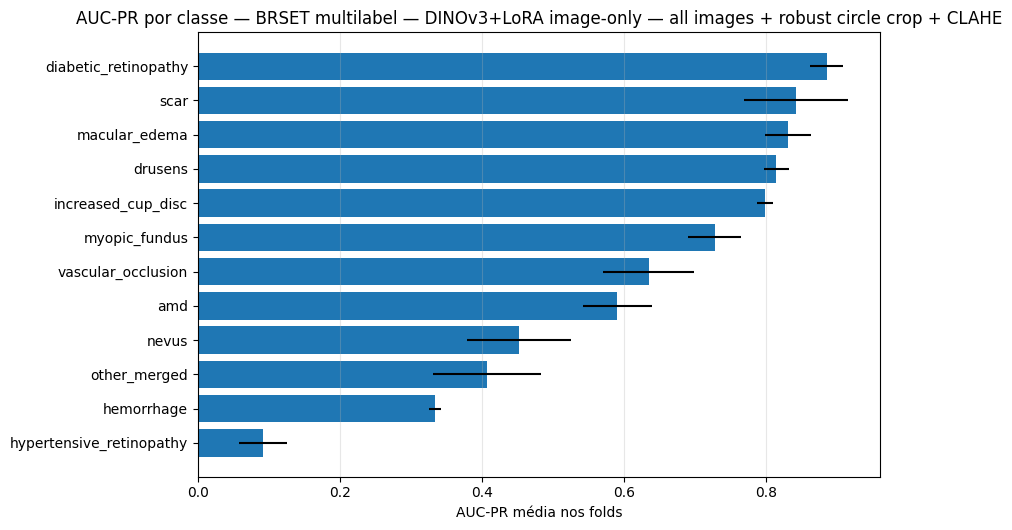

In [23]:
import matplotlib.pyplot as plt

plot_df = per_class_summary.sort_values("auc_pr_mean", ascending=True)
plt.figure(figsize=(9, max(4, 0.45 * len(plot_df))))
plt.barh(plot_df["label"], plot_df["auc_pr_mean"], xerr=plot_df["auc_pr_std"].fillna(0))
plt.xlabel("AUC-PR média nos folds")
plt.title(f"AUC-PR por classe — {TASK_NAME}")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_auc_pr.png"), dpi=150, bbox_inches="tight")
plt.show()

In [24]:
from google.colab import runtime
runtime.unassign()